# Forcing data analysis

The CMIP6 forcing data have been plotted to analyse changing trends. This has been done for all forcing inputs: Temperature, precipitation, shortwave radiation and potential evaporation in the LAR basin. 

The structure of the notebook below is as follows:

##### 1. Startup & Imports
##### 2. Preparing the forcing data
##### 4. 3. Period forcing avg table
##### 4. Yearly forcing avg graph

## 1. Startup & Imports

In [1]:
# Imports

# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import interp1d
from scipy.stats import linregress

# Niceties
from rich import print

In [2]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [4]:
# Defining things

basin_size = 132572
q_critical = 500

# Define only future scenarios
scenarios = ["ssp126", "ssp245", "ssp370"]

# Redefine scenarios to include historical
scenarios_new = ["historical", "ssp126", "ssp245", "ssp370"]

# Attach colours to scenarios to make plotting easier 
colours = {"historical": "tab:blue", "ssp126": "green", "ssp245": "orange", "ssp370": "red"}

# Define periods
periods = [[2025, 2050, 2075],
           [2050, 2075, 2099]]

hist_periods = ([1989], [2014]) 

## 2. Preparing the forcing data

In [5]:
var_names = {"evspsblpot", "pr", "rsds", "tas"}

forcing_data = {}
annual_avg = []
period_avg = []

for scenario in scenarios:

    forcing_data[scenario] = {}

    for var_name in var_names:

        merged_data_list = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            # Define file path
            forcing_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}" / f"combined_CMIP6_{start_year}_{end_year}_{var_name}.nc"
            
            # Load file as dataset
            ds = xr.open_dataset(forcing_file)

            # Load file as array
            da = ds[var_name]

            # Convert to series 
            series = pd.Series(data=da.values.squeeze(),index=pd.to_datetime(da["time"].values).normalize(),name=var_name)

            # Convert pr and evap from km^2/s to mm^2/day
            if var_name in ["pr", "evspsblpot"]:
                series = series * 86400
                annual = series.groupby(series.index.year).sum()

            # Convert temp from Kelvin to Celcius
            elif var_name == "tas":
                series = series - 273.15
                annual = series.groupby(series.index.year).mean()

            elif var_name == "rsds":
                annual = series.groupby(series.index.year).mean()

            # Save for merged time series
            merged_data_list.append(series)

            # Save annual values
            for year, annual_value in annual.items():

                annual_avg.append({
                    "scenario": scenario,
                    "period": f"{start_year}-{end_year}",
                    "year": year,
                    "variable": var_name,
                    "value": annual_value})

            # Save 25 year average
            period_avg.append({
                "scenario": scenario,
                "period": f"{start_year}-{end_year}",
                "variable": var_name,
                "value": annual.mean()})

        # Merge periods into one 2025–2099 series
        merged_data = pd.concat(merged_data_list)
        merged_data = merged_data[~merged_data.index.duplicated(keep="first")]
        merged_data = merged_data.sort_index()

        forcing_data[scenario][var_name] = merged_data

# Create summary table for annual avg values
annual_table = pd.DataFrame(annual_avg)

# Create summary table for period avg values
period_table = pd.DataFrame(period_avg).pivot_table(index=["scenario", "period"],columns="variable",values="value")

In [6]:
# Prepare historical data

def load_hist(start_year, end_year):

    forcing_data_hist = {}
    scenario = "historical"
    forcing_data_hist[scenario] = {}
    annual_avg = []

    for var_name in var_names:

        merged_data_list = []
    
        forcing_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}" / f"combined_CMIP6_{start_year}_{end_year}_{var_name}.nc"

        # Load file as dataset
        ds = xr.open_dataset(forcing_file)

        # Load file as array
        da = ds[var_name]

        # Convert to series 
        series = pd.Series(data=da.values.squeeze(),index=pd.to_datetime(da["time"].values).normalize(),name=var_name)

        # Convert pr and evap from km^2/s to mm^2/day
        if var_name in ["pr", "evspsblpot"]:
            series = series * 86400
            annual = series.groupby(series.index.year).sum()

        # Convert temp from Kelvin to Celcius
        elif var_name == "tas":
            series = series - 273.15
            annual = series.groupby(series.index.year).mean()

        elif var_name == "rsds":
            annual = series.groupby(series.index.year).mean()

        # Save for merged time series
        merged_data_list.append(series)

        # Save annual values
        for year, annual_value in annual.items():

            annual_avg.append({
                "scenario": scenario,
                "period": f"{start_year}-{end_year}",
                "year": year,
                "variable": var_name,
                "value": annual_value})

        # Merge period into one series
        merged_data = pd.concat(merged_data_list)
        merged_data = merged_data[~merged_data.index.duplicated(keep="first")]
        merged_data = merged_data.sort_index()

        forcing_data_hist[scenario][var_name] = merged_data
            
    annual_hist_table = pd.DataFrame(annual_avg)
    
    return annual_hist_table, forcing_data_hist

In [7]:
annual_hist_table,forcing_data_hist = load_hist(start_year=1989,end_year=2014)

annual_hist_table.head()

,scenario,period,year,variable,value
0,historical,1989-2014,1989,tas,2.562430
1,historical,1989-2014,1990,tas,1.319359
2,historical,1989-2014,1991,tas,1.052132
3,historical,1989-2014,1992,tas,0.776736
4,historical,1989-2014,1993,tas,1.499663


## 3. Period forcing avg table

In [14]:
def create_period_forcing_table(annual_table):

    period_forcing_table = (annual_table.groupby(["scenario", "period", "variable"])["value"].mean().reset_index())

    period_forcing_table = period_forcing_table.pivot_table(index=["scenario", "period"], columns="variable", values="value")

    return period_forcing_table

*Table 9: 25 year average forcing data values for future climate scenarios.*

In [17]:
period_forcing_table = round(create_period_forcing_table(annual_table), 1)
period_forcing_table

variable            evspsblpot     pr   rsds  tas
scenario period                                  
ssp126   2025-2050       621.1  633.9  138.5  2.5
         2050-2075       625.8  630.1  138.7  3.0
         2075-2099       621.5  645.3  138.2  2.7
ssp245   2025-2050       628.0  623.0  139.5  2.7
         2050-2075       632.7  637.3  138.3  3.6
         2075-2099       635.6  659.8  137.8  3.6
ssp370   2025-2050       623.4  640.5  138.5  2.7
         2050-2075       636.3  650.3  136.7  4.4
         2075-2099       656.9  645.7  136.6  5.4

In [ ]:
period_forcing_table = round(create_period_forcing_table(annual_table), 1)

period_forcing_table

## 4. Yearly forcing avg graph

In [19]:
def plot_annual_forcing_variable(annual_forcing_table, var_name):

    # Combine historical and scenarios
    annual_forcing_table_all = pd.concat([annual_hist_table, annual_forcing_table],ignore_index=True)
    data = annual_forcing_table_all[annual_forcing_table_all["variable"] == var_name]
    
    plt.figure(figsize=(9, 5))
    
    # Loop through scenarios
    for scenario in scenarios_new:

        # Extract one scenario and colour 
        scenario_data = data[data["scenario"] == scenario]
        colour = colours[scenario]

        # Plot historical 
        if scenario == "historical":
            
            # Plot yearly average 
            plt.plot(scenario_data["year"], scenario_data["value"], color=colour, linewidth=0.3, label=scenario)

            x = scenario_data["year"].values
            y = scenario_data["value"].values

            # Polyfit method for making trendline function
            slope, intercept = np.polyfit(x, y, 1)
            trend = slope * x + intercept

            # Plot trendline
            plt.plot(x,trend,linestyle="--",color=colour)

        # Plot other scenarios
        else:

            # Plot yearly average
            plt.plot(scenario_data["year"], scenario_data["value"], alpha=0.3, color=colour, label=scenario)

        # Look at each 25 year period
        for i in range(len(periods[0])):

            # Define period range
            start_year = periods[0][i]
            end_year = periods[1][i]

            # Adjust data to fit period range
            period_data = scenario_data[
            (scenario_data["year"] >= start_year) & 
            (scenario_data["year"] <= end_year)]

            # Plot trend line over each 25 year period
            if len(period_data) > 1:

                x = period_data["year"].values
                y = period_data["value"].values

                # Polyfit method for making trendline function
                slope, intercept = np.polyfit(x, y, 1)
                trend = slope * x + intercept

                # Plot trendline
                plt.plot(x,trend,linestyle="--",color=colour)

    # Define titles and labels based on var_name
    if var_name == "pr":
        ylabel = "Annual precipitation (mm/year)"
        title = "Annual precipitation in LAR basin by climate scenario"

    elif var_name == "evspsblpot":
        ylabel = "Annual potential evaporation (mm/year)"
        title = "Annual potential evaporation in LAR basin by climate scenario"

    elif var_name == "tas":
        ylabel = "Annual mean temperature increase (°C)"
        title = "Annual mean temperature in LAR basin by climate scenario"

    elif var_name == "rsds":
        ylabel = "Annual mean shortwave radiation (W/m²)"
        title = "Annual mean shortwave radiation in LAR basin by climate scenario"

    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

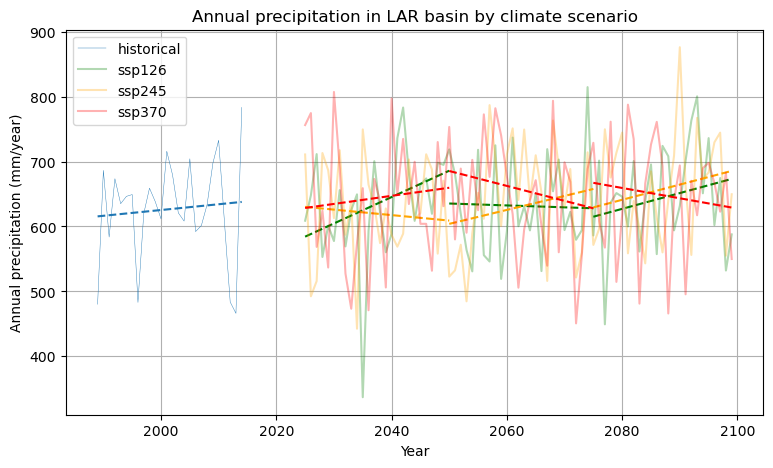

Figure 22: pr-time series for future climate scenarios between 2025-2099 and historical CMIP6 forcings between 
1989-2014.

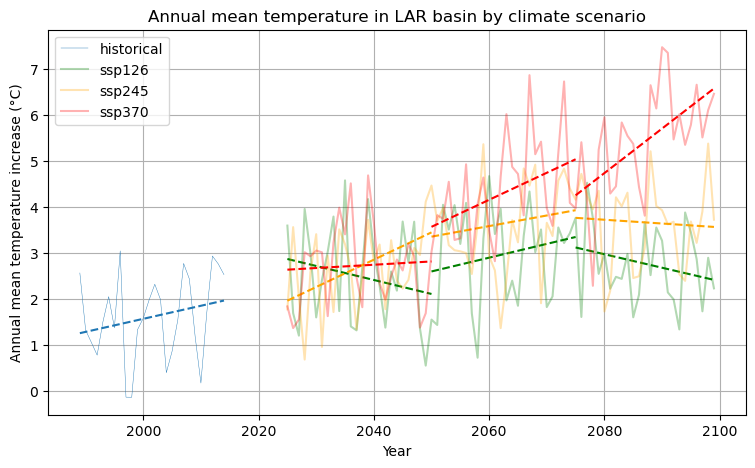

Figure 23: tas-time series for future climate scenarios between 2025-2099 and historical CMIP6 forcings between 
1989-2014.

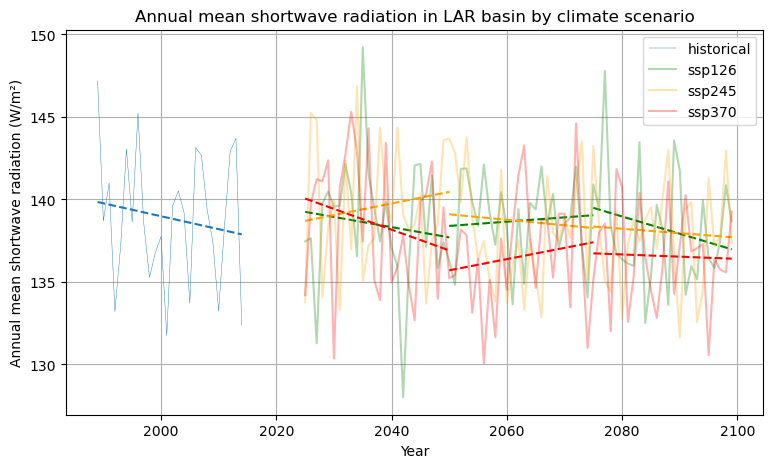

Figure 24: rsds-time series for future climate scenarios between 2025-2099 and historical CMIP6 forcings between 
1989-2014.

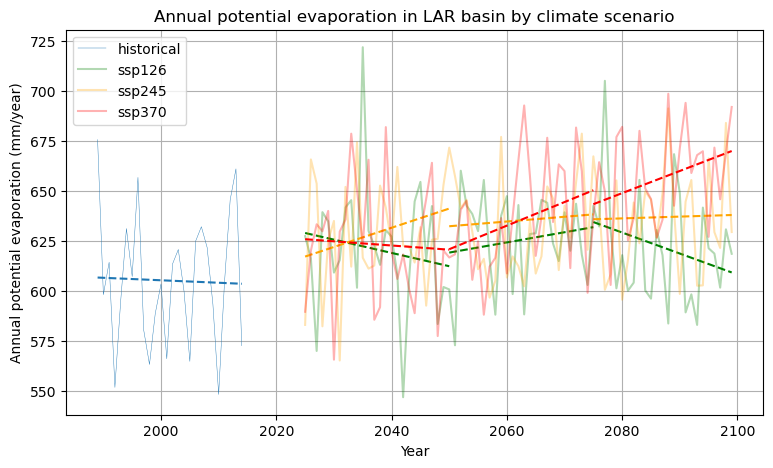

Figure 25: evspsblpot-time series for future climate scenarios between 2025-2099 and historical CMIP6 forcings 
between 1989-2014.

In [29]:
# Define figure number for first figure
n = 22

# Define var names
vars = ["pr", "tas", "rsds", "evspsblpot"]

# Run function to display plots for each var_name in vars
for i in range(len(vars)):
    plot_annual_forcing_variable(annual_table, vars[i])
    print(f"Figure {n + i}: {vars[i]}-time series for future climate scenarios between 2025-2099 and historical CMIP6 forcings between 1989-2014.")